# 01 · Prepare FER2013
Load the Kaggle FER2013 dataset, split it into train/val/test subsets, and persist tensors for later notebooks.

### 블록 1 · 라이브러리 로드
데이터 처리와 시각화를 위해 pandas, NumPy, Matplotlib, PyTorch 등을 불러옵니다.


In [26]:
import json
import os
import random
import subprocess
from collections import Counter
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from PIL import Image


In [ ]:
import sys
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Python path prepared with project root: {PROJECT_ROOT}')


### 블록 2 · 경로 설정
프로젝트 루트와 데이터 저장 경로를 정의하여 이후 셀에서 반복 사용합니다.


In [27]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'
RAW_CSV = DATA_DIR / 'fer2013.csv'
PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f'Project root: {PROJECT_ROOT}')
print(f'Using data dir: {DATA_DIR}')


Project root: /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion
Using data dir: /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/data


### 블록 3 · FER2013 다운로드 확인
로컬에 `fer2013.csv`가 없으면 Kaggle API로 다운로드하고, 이미 있으면 건너뜁니다.


In [28]:
def _ensure_kaggle_credentials() -> tuple[str | None, str | None]:
    user = os.getenv('KAGGLE_USERNAME')
    key = os.getenv('KAGGLE_KEY')
    if user and key:
        return user, key
    creds_path = Path.home() / '.kaggle' / 'kaggle.json'
    if creds_path.exists():
        with open(creds_path, 'r', encoding='utf-8') as fh:
            creds = json.load(fh)
        user = creds.get('username')
        key = creds.get('key')
        if user and key:
            os.environ['KAGGLE_USERNAME'] = user
            os.environ['KAGGLE_KEY'] = key
            print('Loaded Kaggle credentials from ~/.kaggle/kaggle.json')
            return user, key
    return user, key

EMOTION_TO_LABEL = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'sad': 4,
    'surprise': 5,
    'neutral': 6,
}

SPLIT_TO_USAGE = {
    'train': 'Training',
    'test': 'PublicTest',
    'PrivateTest': 'PrivateTest',
}

def build_csv_from_image_dirs() -> None:
    rows = []
    for split_dir, usage in SPLIT_TO_USAGE.items():
        base = DATA_DIR / split_dir
        if not base.exists():
            continue
        for emotion_name, label in EMOTION_TO_LABEL.items():
            emotion_dir = base / emotion_name
            if not emotion_dir.exists():
                continue
            for img_path in emotion_dir.glob('*.jpg'):
                with Image.open(img_path) as img:
                    img = img.convert('L').resize((WIDTH, HEIGHT))
                    pixels = np.asarray(img, dtype=np.uint8).reshape(-1)
                pixel_str = ' '.join(str(int(v)) for v in pixels)
                rows.append({'emotion': label, 'pixels': pixel_str, 'Usage': usage})
    if not rows:
        raise FileNotFoundError('Failed to locate image folders to synthesize fer2013.csv')
    df = pd.DataFrame(rows)
    df.to_csv(RAW_CSV, index=False)
    print(f'Built fer2013.csv from image folders with {len(rows)} samples.')

def maybe_download_fer2013() -> None:
    if RAW_CSV.exists():
        print('Found local fer2013.csv, skipping download.')
        return
    kaggle_user, kaggle_key = _ensure_kaggle_credentials()
    if not kaggle_user or not kaggle_key:
        raise FileNotFoundError('fer2013.csv not found and Kaggle credentials missing. Place the CSV under data/.')
    print('Downloading FER2013 from Kaggle...')
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run(['kaggle', 'datasets', 'download', '-d', 'msambare/fer2013', '-p', str(DATA_DIR), '--force'], check=True)
    zip_path = DATA_DIR / 'fer2013.zip'
    with ZipFile(zip_path, 'r') as zf:
        zf.extractall(DATA_DIR)
    if not RAW_CSV.exists():
        print('fer2013.csv missing after extraction; building from downloaded image folders...')
        build_csv_from_image_dirs()
    print('Dataset prepared.')

maybe_download_fer2013()
assert RAW_CSV.exists(), 'Missing fer2013.csv file.'



Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0



100%|██████████| 60.3M/60.3M [00:00<00:00, 1.71GB/s]


fer2013.csv missing after extraction; building from downloaded image folders...
Built fer2013.csv from image folders with 35887 samples.
Dataset prepared.


### 블록 4 · CSV 로딩
원본 CSV를 pandas로 읽어 데이터 개요를 확인합니다.


In [29]:
df = pd.read_csv(RAW_CSV)
print(df.head())
num_samples = len(df)
print(f'Total samples: {num_samples}')


   emotion                                             pixels     Usage
0        0  181 179 177 175 175 175 173 171 169 166 166 16...  Training
1        0  21 18 27 71 86 81 89 107 112 123 164 187 206 1...  Training
2        0  41 63 85 94 90 81 98 111 108 104 115 124 128 1...  Training
3        0  50 51 51 49 56 81 73 56 42 39 38 39 38 38 46 5...  Training
4        0  41 35 28 19 27 27 23 25 29 26 19 32 110 167 20...  Training
Total samples: 35887


### 블록 5 · 픽셀 파싱
`pixels` 문자열을 48×48 그레이스케일 배열로 변환하고 정규화합니다.


In [30]:
HEIGHT = 48
WIDTH = 48
NUM_CLASSES = 7

def parse_pixels(pixels: str) -> np.ndarray:
    arr = np.fromstring(pixels, sep=' ', dtype=np.float32)
    assert arr.size == HEIGHT * WIDTH, f'Unexpected pixel count {arr.size}'
    return arr

pixel_arrays = np.vstack(df['pixels'].apply(parse_pixels).values)
pixel_arrays = pixel_arrays.reshape(-1, HEIGHT, WIDTH) / 255.0
labels = df['emotion'].astype(np.int64).values
print(f'Pixels tensor shape: {pixel_arrays.shape}')


Pixels tensor shape: (35887, 48, 48)


### 블록 6 · 데이터 분할
학습/검증/테스트 세트를 계층적 분할로 나누고 PyTorch 텐서로 변환합니다.


In [31]:
X_train, X_temp, y_train, y_temp = train_test_split(pixel_arrays, labels, test_size=0.2, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
for split_name, array in [('train', X_train), ('val', X_val), ('test', X_test)]:
    print(f'{split_name}: {array.shape[0]} samples')

def to_tensor(data: np.ndarray) -> torch.Tensor:
    return torch.tensor(data[:, None, :, :], dtype=torch.float32)

torch_splits = {
    'train_images': to_tensor(X_train),
    'val_images': to_tensor(X_val),
    'test_images': to_tensor(X_test),
    'train_labels': torch.tensor(y_train, dtype=torch.long),
    'val_labels': torch.tensor(y_val, dtype=torch.long),
    'test_labels': torch.tensor(y_test, dtype=torch.long),
}


train: 28709 samples
val: 3589 samples
test: 3589 samples


### 블록 7 · 클래스 가중치 계산
학습 세트의 클래스 빈도를 집계해 불균형을 완화할 가중치를 계산합니다.


In [32]:
class_counts = Counter(torch_splits['train_labels'].tolist())
print('Train class counts:', class_counts)
total_train = torch_splits['train_labels'].shape[0]
class_weights = []
for cls in range(NUM_CLASSES):
    count = class_counts.get(cls, 1)
    weight = total_train / (NUM_CLASSES * count)
    class_weights.append(weight)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
torch.save(class_weights_tensor, PROCESSED_DIR / 'class_weights.pt')
print('Class weights:', class_weights_tensor)


Train class counts: Counter({3: 7191, 6: 4958, 4: 4861, 2: 4097, 0: 3962, 5: 3202, 1: 438})
Class weights: tensor([1.0352, 9.3637, 1.0010, 0.5703, 0.8437, 1.2809, 0.8272])


### 블록 8 · 전처리 결과 저장
각 분할의 이미지·레이블 텐서를 `data/processed/`에 저장합니다.


In [33]:
for name, tensor in torch_splits.items():
    out_path = PROCESSED_DIR / f'{name}.pt'
    torch.save(tensor, out_path)
    print(f'Saved {name} -> {out_path}')


Saved train_images -> /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/data/processed/train_images.pt
Saved val_images -> /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/data/processed/val_images.pt
Saved test_images -> /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/data/processed/test_images.pt
Saved train_labels -> /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/data/processed/train_labels.pt
Saved val_labels -> /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/data/processed/val_labels.pt
Saved test_labels -> /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/data/processed/test_labels.pt


### 블록 9 · 시각적 점검
클래스별로 임의의 이미지 예시를 출력해 전처리가 정상인지 확인합니다.


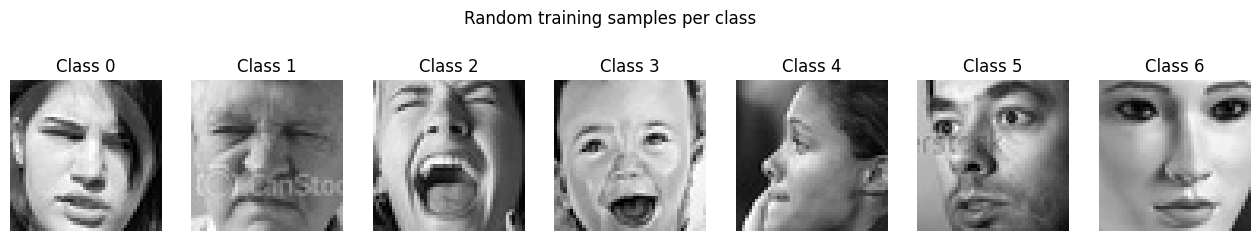

In [38]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 3))
for cls in range(NUM_CLASSES):
    indices = np.where(y_train == cls)[0]
    idx = random.choice(indices) if len(indices) else random.randrange(len(X_train))
    axes[cls].imshow(X_train[idx], cmap='gray')
    axes[cls].set_title(f'Class {cls}')
    axes[cls].axis('off')
plt.suptitle('Random training samples per class')
plt.show()
